In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.optimize as optimize
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [33]:
raw_data = pd.read_excel("LDP_raw data.xlsx")
raw_data

,Grade,LB,UB,Number of borrowers,Number of defaulters,% of defaulters
0,1,777,820,1719,0,0.002327
1,2,727,777,4559,0,0.007238
2,3,677,727,3580,0,0.019832
3,4,627,677,2431,0,0.046483
4,5,577,627,710,0,0.043662
5,6,527,577,135,10,0.074074
6,7,477,527,18,2,0.111111


In [34]:
probability = 75
single_prob_mode = True

In [35]:
total_borrowers = raw_data["Number of borrowers"].sum()

raw_data["Number of borrowers at or below current grade"] = raw_data["Number of borrowers"][::-1].cumsum()[::-1]

#raw_data["cumulative"] =raw_data["Number of borrowers"][::-1].values.cumsum()[::-1]
raw_data["Number of defaulters at or below the current grade"] = raw_data["Number of defaulters"][::-1].cumsum()[::-1]
raw_data["PD_old"] = (raw_data["Number of defaulters at or below the current grade"] / raw_data["Number of borrowers at or below current grade"])*100
if single_prob_mode:
    raw_data = raw_data.drop(columns = raw_data.filter(like="PD_").columns)
    raw_data["PD_Old"] = (raw_data["Number of defaulters at or below the current grade"]/ raw_data["Number of borrowers at or below current grade"])*100
    raw_data[f"PD_{probability}"] = (stats.beta.ppf(probability/100,raw_data["Number of defaulters at or below the current grade"]+1,
                                             raw_data["Number of borrowers at or below current grade"] - raw_data["Number of defaulters at or below the current grade"])*100)
else:
    raw_data = raw_data.drop(columns = raw_data.filter(like = "PD_").columns)
    for i in range(probability,96,10):
        raw_data[f"PD_{i}"] = (stats.beta.ppf(i/100,raw_data["Number of defaulters at or below the current grade"]+1,
                                              raw_data["Number of borrowers at or below current grade"] - 
                                              raw_data["Number of defaulters at or below the current grade"])*100)

raw_data

,Grade,LB,UB,Number of borrowers,Number of defaulters,% of defaulters,Number of borrowers at or below current grade,Number of defaulters at or below the current grade,PD_Old,PD_75
0,1,777,820,1719,0,0.002327,13152,12,0.091241,0.115689
1,2,727,777,4559,0,0.007238,11433,12,0.104959,0.133081
2,3,677,727,3580,0,0.019832,6874,12,0.174571,0.221323
3,4,627,677,2431,0,0.046483,3294,12,0.364299,0.461744
4,5,577,627,710,0,0.043662,863,12,1.390498,1.760009
5,6,527,577,135,10,0.074074,153,12,7.843137,9.840422
6,7,477,527,18,2,0.111111,18,2,11.111111,20.637196


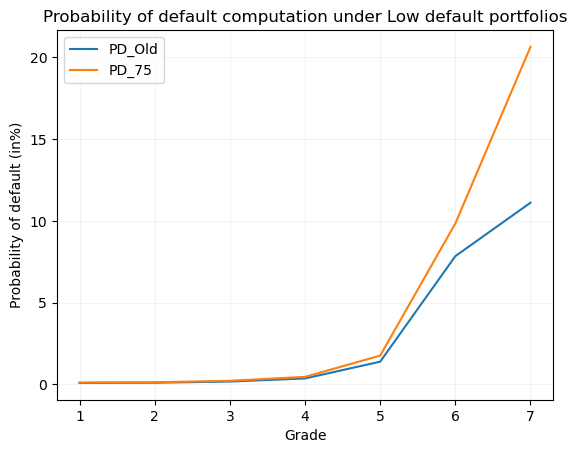

In [36]:
pd_columns = raw_data.filter(like="PD_").columns
for col in pd_columns:
    plt.plot(raw_data["Grade"],raw_data[col], label = col)
plt.xlabel("Grade")
plt.ylabel("Probability of default (in%)")
plt.legend()
plt.grid(alpha = 0.15)
plt.title("Probability of default computation under Low default portfolios")
plt.show()

 + Until now we were assuming borrowers to be uncorrelated.
 
Now, to bring in the correlation, we can use the Vasicek Formula as follows:


In [37]:
list(range(len(raw_data)))

[0, 1, 2, 3, 4, 5, 6]

In [38]:
correlation = 12  # 12%
rho = correlation / 100
trial_runs = 100000
target_cdf = 0.25

np.random.seed(42)
Z = np.random.normal(0, 1, trial_runs)

def pluto_tasche_correlated(p_guess, k, n, Z, rho, target):
    # Bound the guess to prevent normal distribution inf/nan crashes
    p_guess = np.clip(p_guess, 1e-7, 1-1e-7)
        
    p_star = stats.norm.cdf((stats.norm.ppf(p_guess) - np.sqrt(rho) * Z) / np.sqrt(1 - rho))
    p_star = np.clip(p_star,1e-15,1-1e-15)
    
    # Compute the cumulative binomial probabilities across all scenarios
    cumulative_prob = stats.binom.cdf(k=k, n=n, p=p_star)
    
    # Calculate the expected value (mean) of those probabilities
    average = np.mean(cumulative_prob)
    
    # Goal: drive this difference to aprroximately 0
    return average - target

# 3. Running the optimization loop across the 7 grades
correlated_pd_values = []

for i in range(len(raw_data)):
    k = raw_data["Number of defaulters at or below the current grade"].iloc[i]
    n = raw_data["Number of borrowers at or below current grade"].iloc[i]
    
    #try:
        # brentq varies the first argument (p_guess) between 0.001% and 99.9%
    optimized_p = optimize.brentq(
        pluto_tasche_correlated,
        a=1e-5, 
        b=1-1e-5,
        args=(k, n, Z, rho, target_cdf)
    )
    # Convert the decimal result to a percentage for your final column
    correlated_pd_values.append(optimized_p * 100)

#except ValueError:
    # If a grade has data where a 25% threshold is mathematically impossible
#        correlated_pd_values.append(np.nan)

# 4. Append to your master DataFrame
raw_data["PD_Shocked_Correlated"] = correlated_pd_values
raw_data

,Grade,LB,UB,Number of borrowers,Number of defaulters,% of defaulters,Number of borrowers at or below current grade,Number of defaulters at or below the current grade,PD_Old,PD_75,PD_Shocked_Correlated
0,1,777,820,1719,0,0.002327,13152,12,0.091241,0.115689,0.377264
1,2,727,777,4559,0,0.007238,11433,12,0.104959,0.133081,0.423776
2,3,677,727,3580,0,0.019832,6874,12,0.174571,0.221323,0.646133
3,4,627,677,2431,0,0.046483,3294,12,0.364299,0.461744,1.187350
4,5,577,627,710,0,0.043662,863,12,1.390498,1.760009,3.576358
5,6,527,577,135,10,0.074074,153,12,7.843137,9.840422,14.633714
6,7,477,527,18,2,0.111111,18,2,11.111111,20.637196,25.106226


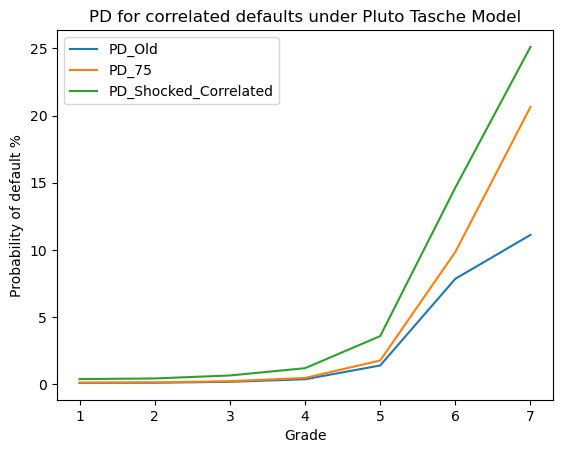

In [39]:
plot_columns = raw_data.filter(like="PD_").columns
for col in plot_columns:
    plt.plot(raw_data["Grade"],raw_data[col], label = col)

plt.xlabel("Grade")
plt.ylabel("Probability of default %")
plt.legend()
plt.title("PD for correlated defaults under Pluto Tasche Model")
plt.show()

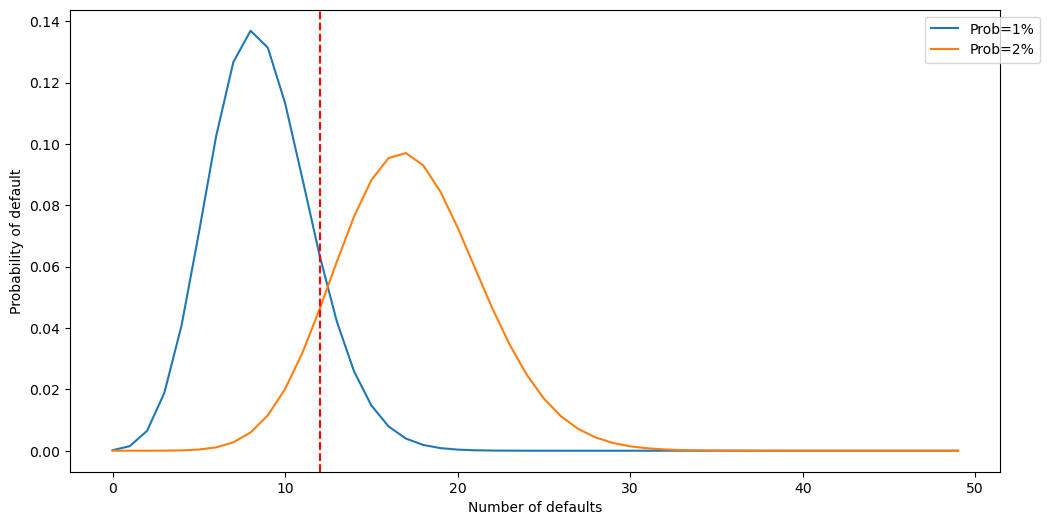

In [50]:
number_of_borrowers = 863 # Number of borrowers at or below the Grade 5
number_of_defaults = 12 # Number of defaults at or below Grade 5

illustration = pd.DataFrame()
illustration["Number of defaults"] = list(range(0,50,1)) # change the upper bound for default counts
upper_bound_prob = round((number_of_defaults / number_of_borrowers)*100)
for i in range(upper_bound_prob,upper_bound_prob+2,1): # Reprsents the probability as the starting point.
    illustration[f"Prob={i}%"] = stats.binom.pmf(k = illustration["Number of defaults"],
                                                n = number_of_borrowers,
                                                p = i/100)
    
    # To see the CDF plot, de comment the below: 
    #illustration[f"Cumulative_Prob={i}%"] = stats.binom.cdf(k = illustration["Number of defaults"],
    #                                            n = number_of_borrowers,
    #                                            p = i/100)

plot_columns = illustration.filter(like="Prob=").columns
plt.figure(figsize=(12, 6))
for col in plot_columns:
    plt.plot(illustration["Number of defaults"],illustration[col], label = col)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.axvline(x=number_of_defaults, linestyle="dashed", color="red")
plt.xlabel("Number of defaults")
plt.ylabel("Probability of default")
plt.show()

# CDF Plot - Visualising the 75% confidence level

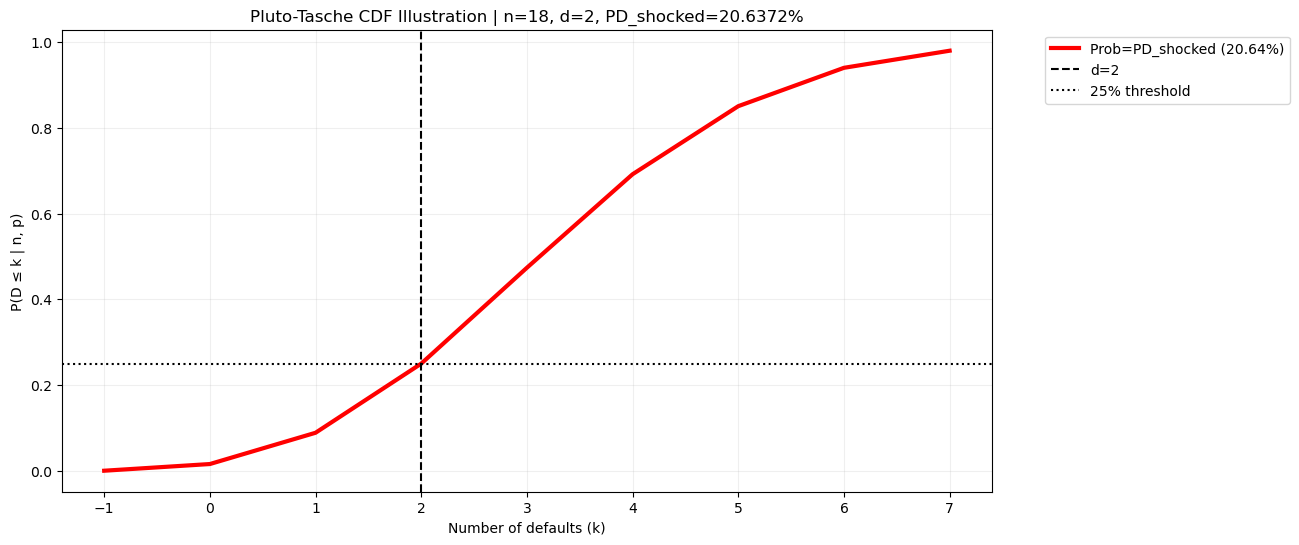

In [14]:
number_of_borrowers = 18
number_of_defaults = 2

# try the following example values for (number_of_borrowers, number_of_defaults) combination: 
# 1. 1719, 4
# 2. 4559, 33
# 3. 3580, 71
# 4. 2431 , 113
# 5. 710 , 31
# 6. 135, 10
# 7. 18, 2


pd_shocked = stats.beta.ppf(0.75, number_of_defaults + 1, 
                      number_of_borrowers - number_of_defaults)

# x-axis centered around default counts
# creating boundary values for x axis given the number of defaults as : n*p +/- 3*sqrt(n*p*(1-p))

x_low = int((number_of_borrowers * pd_shocked) - (3*np.sqrt(number_of_borrowers * pd_shocked*(1-pd_shocked))))
x_high =int((number_of_borrowers * pd_shocked) + (3*np.sqrt(number_of_borrowers * pd_shocked*(1-pd_shocked))))

x_values = list(range(x_low, x_high, 1))
illustration = pd.DataFrame()
illustration["Number of defaults"] = x_values


# Integer curves straddling shocked PD
prob_low = int(pd_shocked - 0.04)
prob_high = int(pd_shocked +0.04)
for i in range(prob_low, prob_high, 1):
    illustration[f"Prob={i}%"] = stats.binom.cdf(
        k=illustration["Number of defaults"],
        n=number_of_borrowers,
        p=i/100
    )

# Exact shocked PD curve
illustration[f"Prob=PD_shocked ({pd_shocked:.2%})"] = stats.binom.cdf(k=illustration["Number of defaults"],
                                                                      n=number_of_borrowers,p=pd_shocked)

plot_columns = illustration.filter(like="Prob=").columns

plt.figure(figsize=(12, 6))
for col in plot_columns:
    if "shocked" in col:
        plt.plot(illustration["Number of defaults"], illustration[col],
                 label=col, linewidth=3, color='red', linestyle='solid')
    else:
        plt.plot(illustration["Number of defaults"], illustration[col], 
                 label=col, alpha=0.6)

plt.axvline(x=number_of_defaults, linestyle="dashed", 
            color='black', label=f'd={number_of_defaults}')
plt.axhline(y=0.25, linestyle="dotted", 
            color='black', label='25% threshold')

plt.xlabel("Number of defaults (k)")
plt.ylabel("P(D ≤ k | n, p)")
plt.title(f"Pluto-Tasche CDF Illustration | n={number_of_borrowers}, d={number_of_defaults}, PD_shocked={pd_shocked:.4%}")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.2)
plt.show()

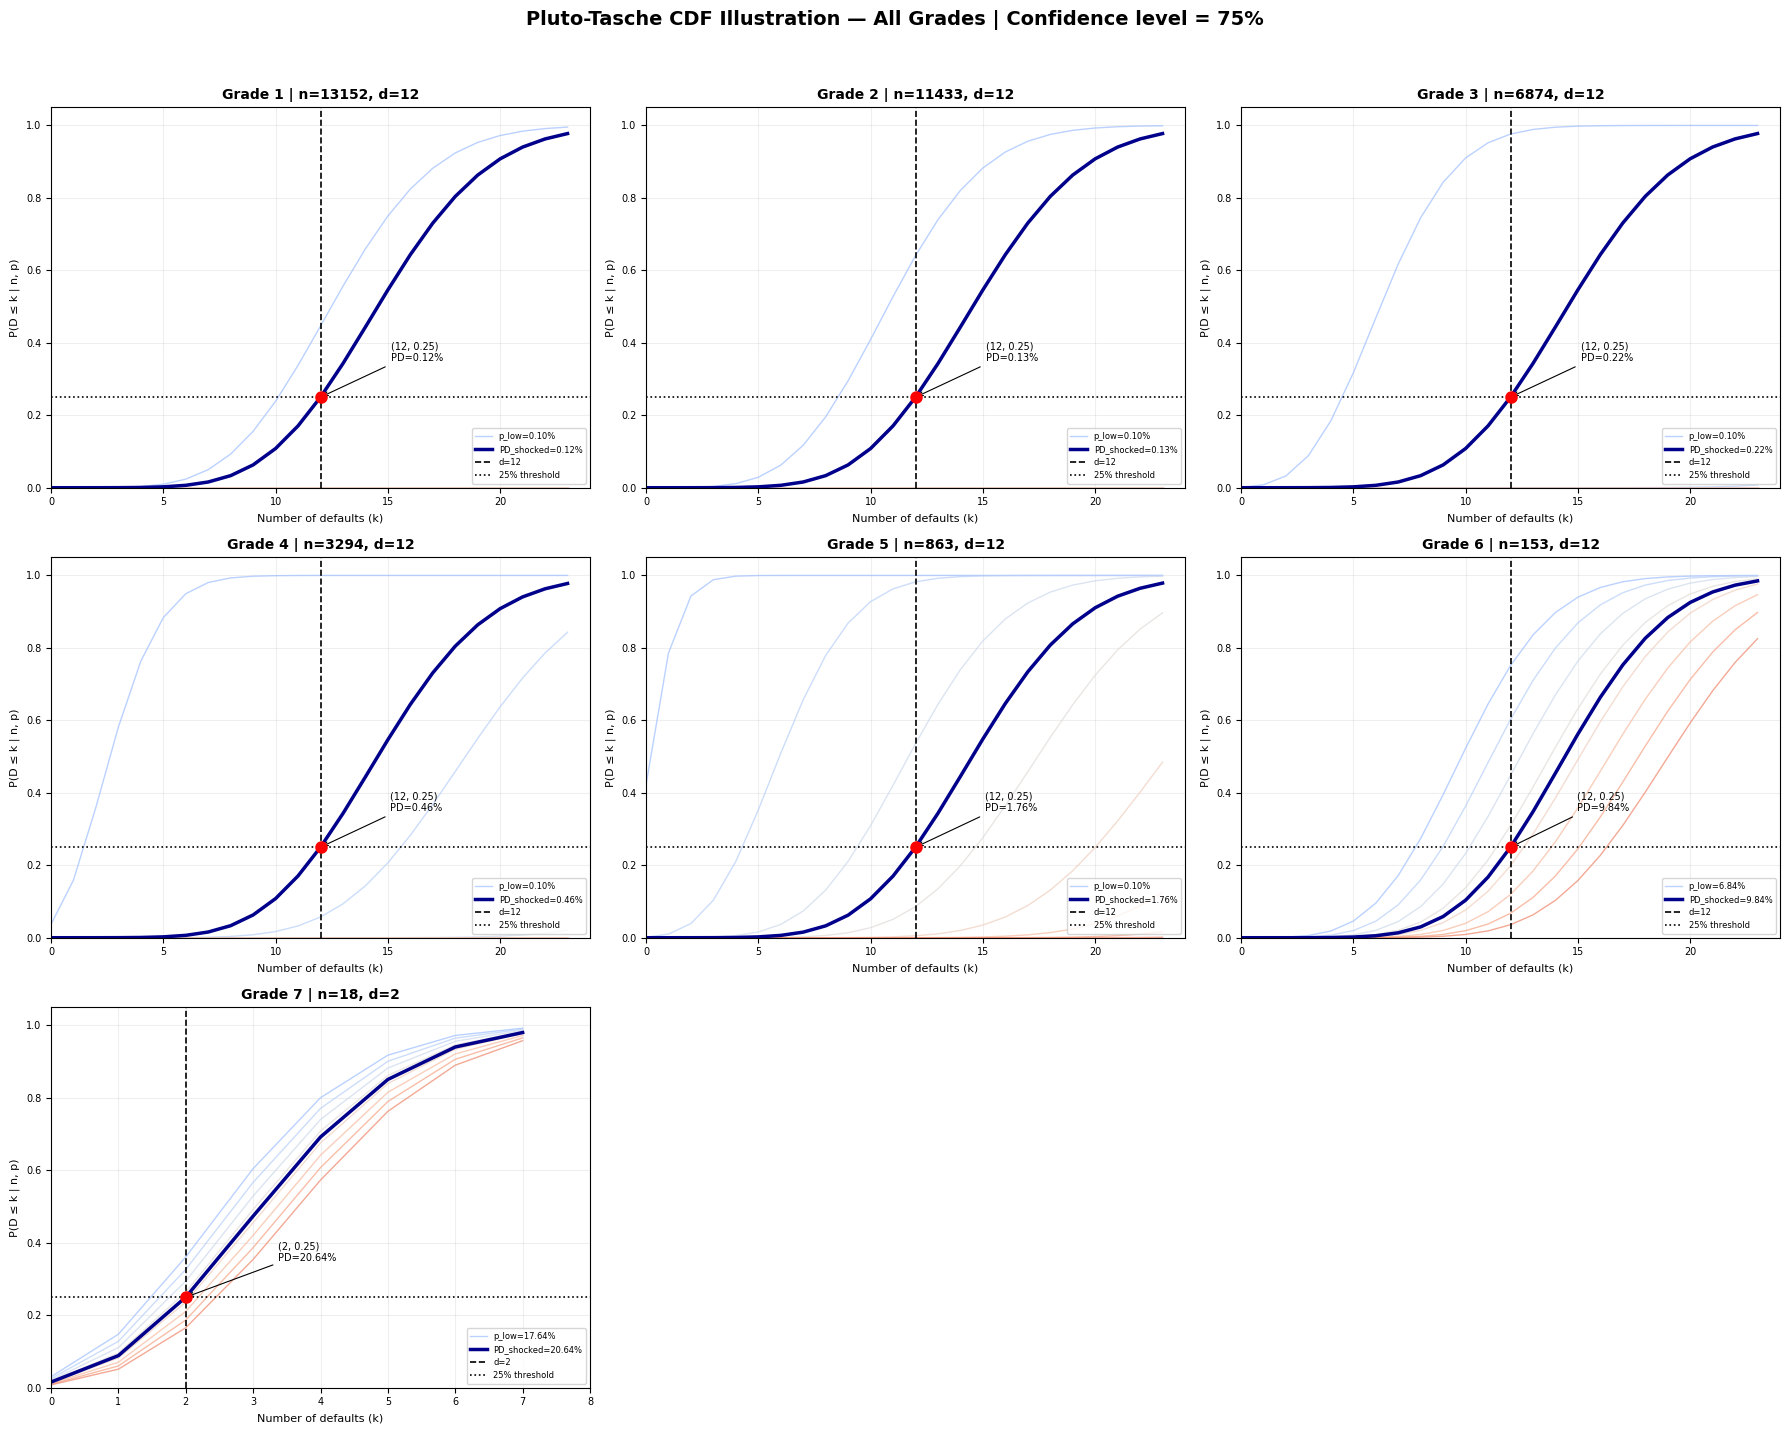

In [31]:
# All Grades example: 

grades = [
    {"grade": 1, "n": 13152, "d": 12},
    {"grade": 2, "n": 11433, "d": 12},
    {"grade": 3, "n": 6874,  "d": 12},
    {"grade": 4, "n": 3294,  "d": 12},
    {"grade": 5, "n": 863,   "d": 12},
    {"grade": 6, "n": 153,   "d": 12},
    {"grade": 7, "n": 18,    "d": 2},
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, g in enumerate(grades):
    ax = axes[idx]
    n, d = g["n"], g["d"]
    
    pd_old     = d / n
    pd_shocked = stats.beta.ppf(0.75, d + 1, n - d)
    sigma      = np.sqrt(n * pd_shocked * (1 - pd_shocked))
    
    # x-axis
    x_low  = max(0, int(d - 3 * sigma))
    x_high = int(d + 3 * sigma) + 1
    x_vals = np.arange(x_low, x_high)
    
    # probability-range: 8 evenly spaced curves showing shocked PD
    p_low   = max(0.001, pd_shocked - 0.03)
    p_high  = min(0.999, pd_shocked + 0.03)
    p_steps = np.linspace(p_low, p_high, 8)
    
    # Plot surrounding curves
    cmap = plt.cm.coolwarm(np.linspace(0.3, 0.8, len(p_steps)))
    for p, color in zip(p_steps, cmap):
        y = stats.binom.cdf(x_vals, n, p)
        ax.plot(x_vals, y, color=color, alpha=0.7, linewidth=1,
                label=f"{p:.2%}")
    
    # Plotting shocked PD curve in red
    y_shocked = stats.binom.cdf(x_vals, n, pd_shocked)
    ax.plot(x_vals, y_shocked, color='darkblue', linewidth=2.5,
            label=f"PD_shocked ({pd_shocked:.2%})")
    
    # Reference lines
    ax.axvline(x=d,linestyle="dashed", color='black',linewidth=1.2,label=f"d={d}")
    ax.axhline(y=0.25,linestyle="dotted", color='black',linewidth=1.2,label="25% threshold")
    
    # Annotate intersection point
    ax.plot(d, 0.25, 'o', color='red', markersize=8, zorder=5)
    ax.annotate(f"({d}, 0.25)\nPD={pd_shocked:.2%}",
                xy=(d, 0.25),
                xytext=(d + sigma * 0.8, 0.35),
                fontsize=7,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
    
    ax.set_xlim(x_low, x_high)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Grade {g['grade']} | n={n}, d={d}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Number of defaults (k)", fontsize=8)
    ax.set_ylabel("P(D ≤ k | n, p)", fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=7)
    
    # Compact legend showing only shocked PD + boundary curves
    handles, labels = ax.get_legend_handles_labels()
    ax.legend([handles[0], handles[-3], handles[-2], handles[-1]],
              [f"p_low={p_steps[0]:.2%}", f"PD_shocked={pd_shocked:.2%}", 
               f"d={d}", "25% threshold"],
              fontsize=6, loc='lower right')

# Hide unused subplots (3x3 grid = 9 slots, 7 grades)
for idx in range(len(grades), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Pluto-Tasche CDF Illustration — All Grades | Confidence level = 75%",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
#handles, labels = ax.get_legend_handles_labels()
#for i, label in enumerate(labels):
#    print(f"handles[{i}] / handles[{i - len(labels)}] → {label}")
#print(plt.colormaps())